In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import spacy

# Download necessary NLTK resources 
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

# Loading the spaCy English model
nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package punkt to /Users/alankar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alankar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/alankar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/alankar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/alankar/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Text Preprocessing

In [4]:
# Reading the CSV file
df = pd.read_csv('cyberbullying_tweets.csv')

# Filtering out rows with empty or missing tweets in 'tweet_text'
df = df[df['tweet_text'].notnull()]
df = df[df['tweet_text'].str.strip() != '']

# Defining a function for text cleaning and tokenisation
def clean_text(text):
    if not text.strip():
        return []  # Returns empty list if text is empty
    # To convert the text to lowercase 
    text = text.lower()
    # To remove punctuation and special characters (keeping only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # To tokenise the text
    tokens = word_tokenize(text)
    # Removing stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Applying stemming
    ps = PorterStemmer()
    tokens_stemmed = [ps.stem(word) for word in tokens]
    # Applying lemmatisation
    lemmatizer = WordNetLemmatizer()
    tokens_lemmatized = [lemmatizer.lemmatize(word) for word in tokens_stemmed]
    return tokens_lemmatized
    
# Apply the cleaning function to create new columns for tokens and reconstructed text
df['clean_tokens'] = df['tweet_text'].apply(clean_text)
df['clean_text'] = df['clean_tokens'].apply(lambda tokens: ' '.join(tokens))

## Bag of Words

In [5]:
# Generating Bag-of-Words (BoW) representation
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(df['clean_text'])
print("Bag-of-Words shape:", bow_matrix.shape)

Bag-of-Words shape: (47692, 53201)


## TF-IDF

In [6]:
# Generate TF-IDF representation
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])
print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (47692, 53201)


## Part-of-speech Tagging

In [7]:
# Part-of-Speech (POS) tagging using NLTK
df['pos_tags'] = df['clean_tokens'].apply(lambda tokens: nltk.pos_tag(tokens) if tokens else [])

## Chunking

In [8]:
# Chunking: using a simple noun phrase (NP) chunker with NLTK
grammar = "NP: {<DT>?<JJ>*<NN>}"
chunk_parser = nltk.RegexpParser(grammar)
def chunk_text(pos_tags):
    if not pos_tags:
        return None
    tree = chunk_parser.parse(pos_tags)
    return tree
df['chunks'] = df['pos_tags'].apply(chunk_text)

## VADER Sentiment Analysis

In [9]:
# VADER Sentiment Analysis
sia = SentimentIntensityAnalyzer()
def vader_sentiment(text):
    if not text.strip():
        return {}
    return sia.polarity_scores(text)
df['vader_sentiment'] = df['clean_text'].apply(vader_sentiment)

## Textblob Sentiment Analysis

In [10]:
# TextBlob Sentiment Analysis
def textblob_sentiment(text):
    if not text.strip():
        return None
    blob = TextBlob(text)
    return blob.sentiment  # Returns a tuple: (polarity, subjectivity)
df['textblob_sentiment'] = df['clean_text'].apply(textblob_sentiment)

## Named Entity Recognition

In [11]:
# Named Entity Recognition (NER) using spaCy
def extract_entities(text):
    if not text.strip():
        return []
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]
df['named_entities'] = df['tweet_text'].apply(extract_entities)

## Displaying a few examples

In [12]:
# Show a few processed examples
print(df.head())

                                          tweet_text cyberbullying_type  \
0  In other words #katandandre, your food was cra...  not_cyberbullying   
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying   
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying   
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying   
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying   

                                        clean_tokens  \
0           [word, katandandr, food, crapilici, mkr]   
1  [aussietv, white, mkr, theblock, imacelebritya...   
2  [xochitlsuckkk, classi, whore, red, velvet, cu...   
3  [jasongio, meh, p, thank, head, concern, anoth...   
4  [rudhoeenglish, isi, account, pretend, kurdish...   

                                          clean_text  \
0                 word katandandr food crapilici mkr   
1  aussietv white mkr theblock imacelebrityau tod...   
2       xochitlsuckkk classi whore red velve

# Exploratory Data Analysis

In [13]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

## Cyberbullying types

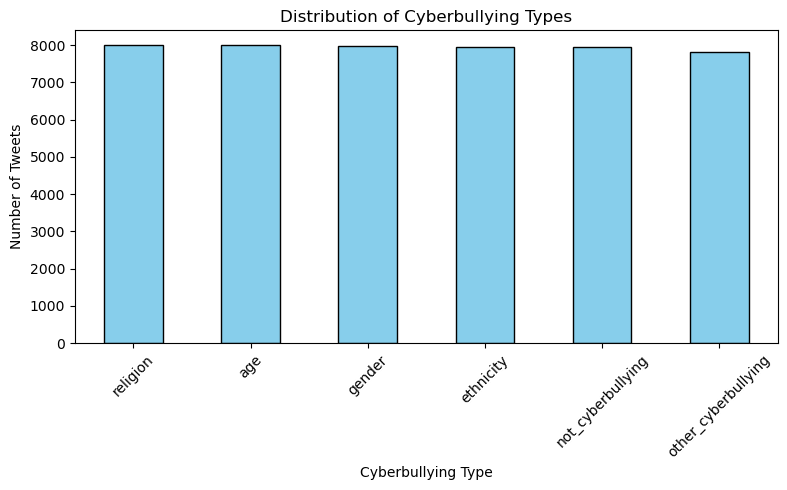

In [14]:
# Distribution of Cyberbullying Types

cyberbullying_counts = df['cyberbullying_type'].value_counts()
plt.figure(figsize=(8, 5))
cyberbullying_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Cyberbullying Types')
plt.xlabel('Cyberbullying Type')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## VADER Compound Sentiment Scores

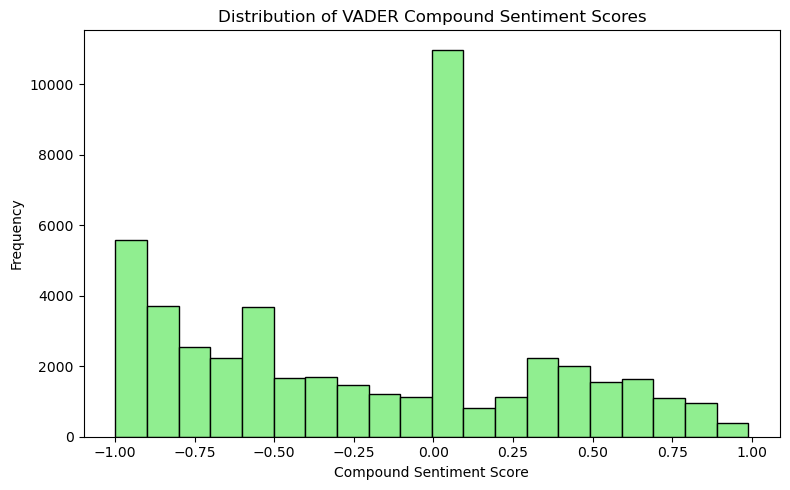

In [15]:
# Distribution of VADER Compound Sentiment Scores

compound_scores = df['vader_sentiment'].apply(lambda x: x['compound'] if x else 0)
plt.figure(figsize=(8, 5))
plt.hist(compound_scores, bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of VADER Compound Sentiment Scores')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Word Cloud

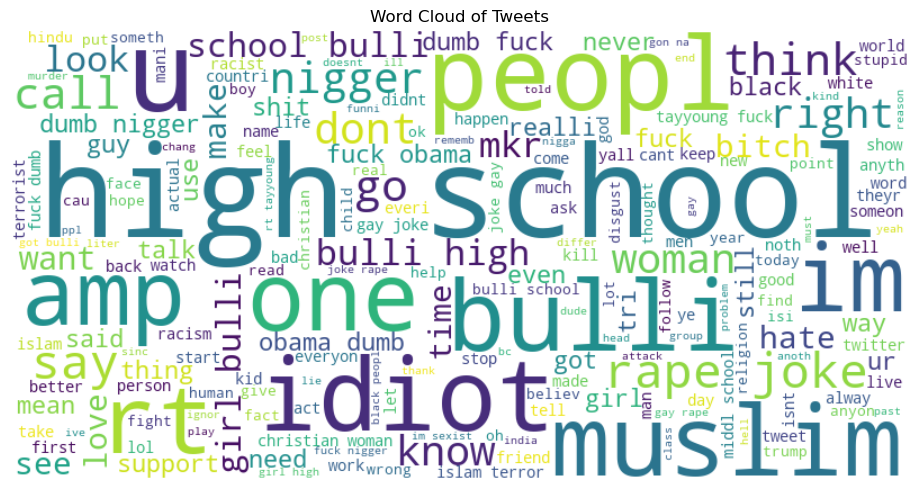

In [16]:
# Word Cloud of Cleaned Tweet Text
all_text = " ".join(df['clean_text'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweets')
plt.tight_layout()
plt.show()

## Top 20 most commmon words

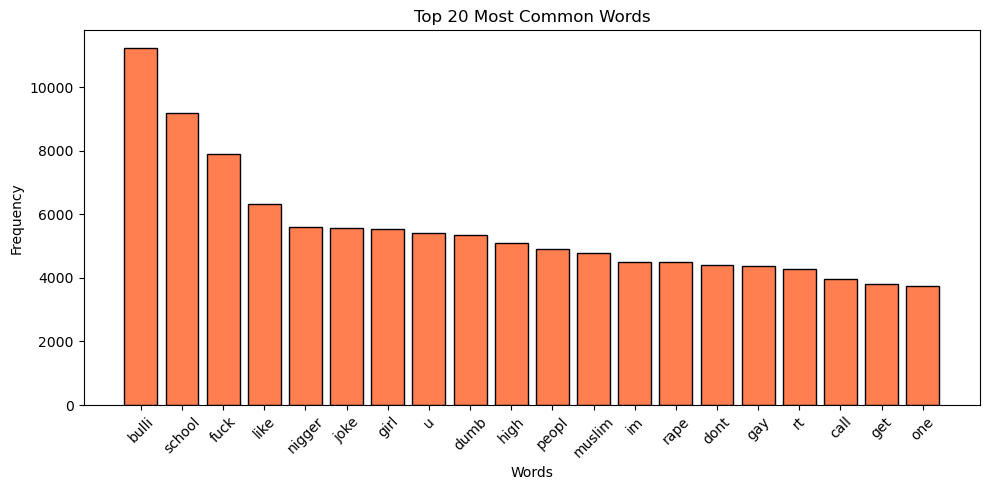

In [17]:
# Top 20 Most Common Words
# Flatten the list of tokens to get a single list of words
all_tokens = [token for tokens in df['clean_tokens'] for token in tokens]
token_counts = Counter(all_tokens)
common_words = token_counts.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='coral', edgecolor='black')
plt.title('Top 20 Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature Extraction

In [19]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer

# Extracting VADER Scores 
df['vader_neg'] = df['vader_sentiment'].apply(lambda x: x['neg'] if x else 0)
df['vader_neu'] = df['vader_sentiment'].apply(lambda x: x['neu'] if x else 0)
df['vader_pos'] = df['vader_sentiment'].apply(lambda x: x['pos'] if x else 0)
df['vader_compound'] = df['vader_sentiment'].apply(lambda x: x['compound'] if x else 0)

# Extracting TextBlob Scores 
df['textblob_polarity'] = df['textblob_sentiment'].apply(lambda x: x.polarity if x else 0)
df['textblob_subjectivity'] = df['textblob_sentiment'].apply(lambda x: x.subjectivity if x else 0)

# Token Count
df['token_count'] = df['clean_tokens'].apply(len)

# Named Entity Count 
df['entity_count'] = df['named_entities'].apply(len)

# POS Tag Ratios 
def get_pos_ratios(pos_tags):
    """Return ratios of nouns, verbs, adjectives, and adverbs."""
    if not pos_tags:
        return (0, 0, 0, 0)
    nouns = sum(1 for (_, tag) in pos_tags if tag.startswith('NN'))
    verbs = sum(1 for (_, tag) in pos_tags if tag.startswith('VB'))
    adjs  = sum(1 for (_, tag) in pos_tags if tag.startswith('JJ'))
    advs  = sum(1 for (_, tag) in pos_tags if tag.startswith('RB'))
    total = len(pos_tags)
    return (nouns / total, verbs / total, adjs / total, advs / total)

df['noun_ratio'], df['verb_ratio'], df['adj_ratio'], df['adv_ratio'] = zip(*df['pos_tags'].apply(get_pos_ratios))

# To assemble Numeric Features
numeric_cols = [
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
    'textblob_polarity', 'textblob_subjectivity',
    'token_count', 'entity_count',
    'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio'
]
numeric_features = df[numeric_cols].values

## TF-IDF Features

In [22]:
# We can limit max_features to reduce dimensionality if desired
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

# Combine the sparse TF-IDF matrix with the dense numeric feature matrix
# We convert numeric_features to a sparse matrix before hstack
numeric_features_sparse = sp.csr_matrix(numeric_features)
X = sp.hstack([X_tfidf, numeric_features_sparse])

In [28]:
# To print the shape of the TF-IDF matrix and some sample feature names
print("TF-IDF shape:", X_tfidf.shape)
print("Sample TF-IDF feature names:", tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF shape: (47692, 5000)
Sample TF-IDF feature names: ['aa' 'aalwuhaib' 'ab' 'abandon' 'abc' 'abdul' 'abe' 'abil' 'abl'
 'ableist' 'abolish' 'abort' 'abroad' 'absolut' 'absurd' 'abt' 'abu'
 'abunaseeha' 'abus' 'ac']


In [29]:
# Summary statistics for numeric features
numeric_summary = pd.DataFrame(numeric_features, columns=numeric_cols).describe()
print("Numeric Features Summary:")
print(numeric_summary)

Numeric Features Summary:
          vader_neg     vader_neu     vader_pos  vader_compound  \
count  47692.000000  47692.000000  47692.000000    47692.000000   
mean       0.218951      0.659945      0.120288       -0.206595   
std        0.227532      0.241244      0.148196        0.526604   
min        0.000000      0.000000      0.000000       -0.999100   
25%        0.000000      0.486000      0.000000       -0.700300   
50%        0.180000      0.655000      0.076000       -0.102700   
75%        0.364000      0.843000      0.206000        0.077200   
max        1.000000      1.000000      1.000000        0.989400   

       textblob_polarity  textblob_subjectivity   token_count  entity_count  \
count       47692.000000           47692.000000  47692.000000  47692.000000   
mean           -0.031032               0.389251     13.788120      1.504173   
std             0.303433               0.290220      8.422069      1.779222   
min            -1.000000               0.000000      0

# Machine Learning (Classification)

In [37]:
# Shifting numeric features if any negative values exist
min_val = numeric_features.min()
if min_val < 0:
    print("Shifting numeric features by", abs(min_val))
    numeric_features = numeric_features + abs(min_val)

# Converting numeric features to a sparse matrix and combine with TF-IDF
numeric_features_sparse = sp.csr_matrix(numeric_features)
X = sp.hstack([X_tfidf, numeric_features_sparse])

# Defining target variable
y = df['cyberbullying_type']

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training and Evaluation
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Naive Bayes

In [38]:
# Naive Bayes 
nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:
                     precision    recall  f1-score   support

                age       0.83      0.92      0.87      1603
          ethnicity       0.91      0.83      0.87      1603
             gender       0.85      0.76      0.80      1531
  not_cyberbullying       0.60      0.51      0.55      1624
other_cyberbullying       0.60      0.67      0.64      1612
           religion       0.82      0.91      0.86      1566

           accuracy                           0.77      9539
          macro avg       0.77      0.77      0.77      9539
       weighted avg       0.77      0.77      0.76      9539



## Support Vector Machine (SVM)

In [39]:
# Support Vector Machine 
svm_clf = LinearSVC(random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


SVM Classification Report:
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1603
          ethnicity       0.98      0.97      0.98      1603
             gender       0.88      0.84      0.86      1531
  not_cyberbullying       0.59      0.54      0.56      1624
other_cyberbullying       0.60      0.67      0.63      1612
           religion       0.95      0.96      0.95      1566

           accuracy                           0.82      9539
          macro avg       0.83      0.82      0.82      9539
       weighted avg       0.82      0.82      0.82      9539



/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Random Forest

In [40]:
# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
                     precision    recall  f1-score   support

                age       0.97      0.98      0.97      1603
          ethnicity       0.99      0.97      0.98      1603
             gender       0.89      0.80      0.84      1531
  not_cyberbullying       0.53      0.52      0.52      1624
other_cyberbullying       0.53      0.61      0.57      1612
           religion       0.95      0.95      0.95      1566

           accuracy                           0.80      9539
          macro avg       0.81      0.80      0.81      9539
       weighted avg       0.81      0.80      0.80      9539



## Model Comparison

Model Performance Comparison:
                   Naive Bayes       SVM  Random Forest
Accuracy              0.765908  0.823252       0.801342
Macro F1-Score        0.765155  0.824527       0.805743
Weighted F1-Score     0.763914  0.823013       0.804063


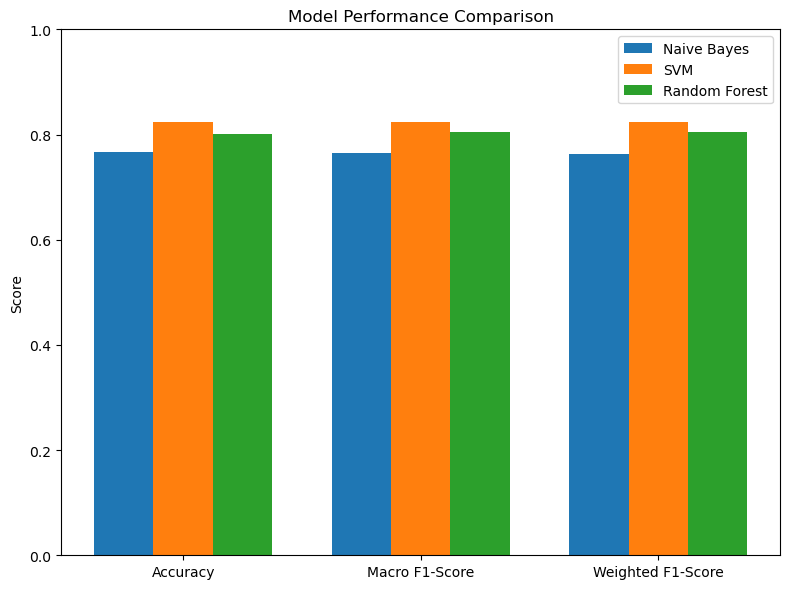

In [41]:
# Obtaining classification reports as dictionaries (with overall metrics)
report_nb = classification_report(y_test, y_pred_nb, output_dict=True)
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Creating a DataFrame to compare key metrics: Accuracy, Macro F1-Score, and Weighted F1-Score
comparison_df = pd.DataFrame({
    'Naive Bayes': [report_nb['accuracy'], report_nb['macro avg']['f1-score'], report_nb['weighted avg']['f1-score']],
    'SVM': [report_svm['accuracy'], report_svm['macro avg']['f1-score'], report_svm['weighted avg']['f1-score']],
    'Random Forest': [report_rf['accuracy'], report_rf['macro avg']['f1-score'], report_rf['weighted avg']['f1-score']]
}, index=['Accuracy', 'Macro F1-Score', 'Weighted F1-Score'])

print("Model Performance Comparison:")
print(comparison_df)

# Plotting the comparison as a bar chart
metrics = ['Accuracy', 'Macro F1-Score', 'Weighted F1-Score']
nb_scores = [report_nb['accuracy'], report_nb['macro avg']['f1-score'], report_nb['weighted avg']['f1-score']]
svm_scores = [report_svm['accuracy'], report_svm['macro avg']['f1-score'], report_svm['weighted avg']['f1-score']]
rf_scores = [report_rf['accuracy'], report_rf['macro avg']['f1-score'], report_rf['weighted avg']['f1-score']]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(x - width, nb_scores, width, label='Naive Bayes')
ax.bar(x, svm_scores, width, label='SVM')
ax.bar(x + width, rf_scores, width, label='Random Forest')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()

plt.tight_layout()
plt.show()